# 05 - Machine Learning Regime Filter

## Objectif

Améliorer le filtre de régime SMA200 avec un modèle ML (Logistic Regression).

**Approche:**
- Prédire si le marché sera en hausse ou baisse sur le mois suivant
- Utiliser des features simples et interprétables
- Validation temporelle stricte (pas de look-ahead bias)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

from src.data_loader import load_universe_data, load_benchmark_data, load_benchmark_daily
from src.backtest import run_backtest, compute_drawdowns
from src.regime_filter import compute_regime_filter
from src.ml_regime import (
    compute_features, compute_target, train_model,
    predict_regime, get_feature_importance,
    compute_ml_regime_signal, compare_regimes
)
from src.metrics import compute_metrics
from src.config import get_config

config = get_config()

In [2]:
prices = load_universe_data(verbose=False)
benchmark = load_benchmark_data(verbose=False)
benchmark_daily = load_benchmark_daily(verbose=False)

spy = benchmark_daily.iloc[:, 0]
print(f"Période: {spy.index[0].date()} - {spy.index[-1].date()}")

Période: 2005-01-03 - 2024-12-30


## 1. Construction des features

On utilise des indicateurs simples et interprétables:

| Feature | Description | Intuition |
|---------|-------------|-----------|
| mom_1m | Momentum 1 mois | Tendance court terme |
| mom_3m | Momentum 3 mois | Tendance moyen terme |
| mom_6m | Momentum 6 mois | Tendance long terme |
| vol_20d | Volatilité 20j | Risque actuel |
| vol_60d | Volatilité 60j | Risque moyen |
| vol_ratio | vol_20d / vol_60d | Stress indicator |
| price_sma50 | Prix vs SMA50 | Position vs tendance |
| price_sma200 | Prix vs SMA200 | Position vs tendance LT |

In [3]:
features = compute_features(spy)
print(f"Features calculées: {len(features)} observations")
features.tail()

Features calculées: 4833 observations


,mom_1m,mom_3m,mom_6m,vol_20d,vol_60d,vol_ratio,price_sma50,price_sma200
Date,,,,,,,,
2024-12-23,0.005090,0.044445,0.098548,0.134339,0.123587,1.086997,0.008392,0.084879
2024-12-24,0.013121,0.058389,0.109374,0.139521,0.125235,1.114072,0.018946,0.095973
2024-12-26,0.009763,0.054279,0.107701,0.138412,0.123565,1.120158,0.018203,0.095137
2024-12-27,-0.006056,0.044696,0.100371,0.143250,0.125807,1.138645,0.006985,0.082765
2024-12-30,-0.014412,0.028653,0.085580,0.146551,0.128185,1.143277,-0.004770,0.069632


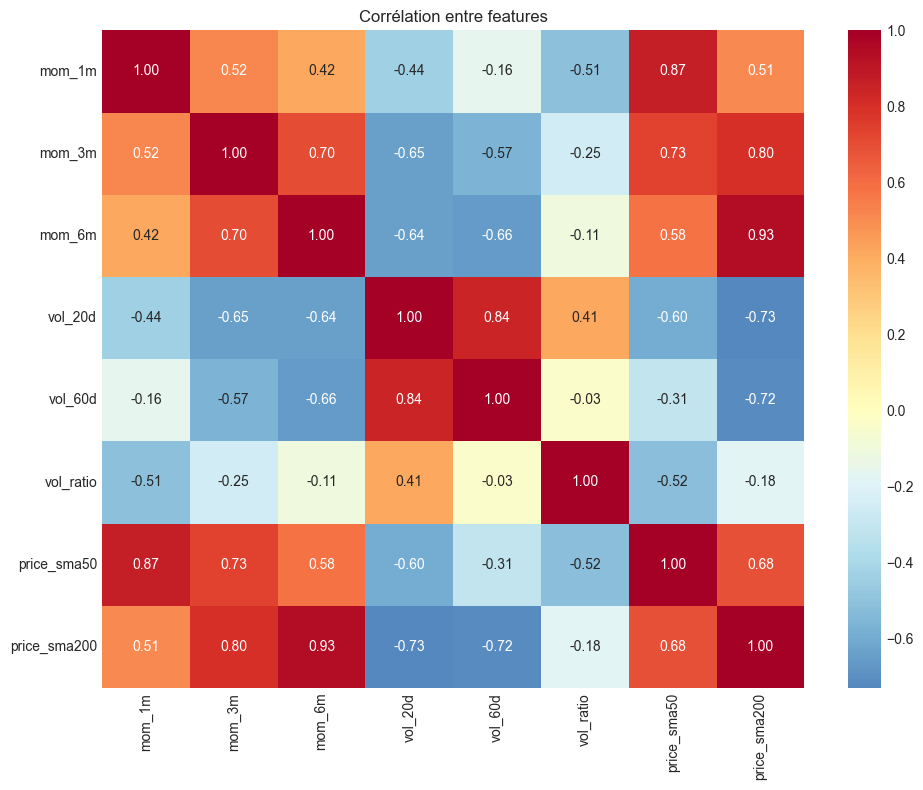

In [4]:
# Corrélation entre features
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', ax=ax)
ax.set_title('Corrélation entre features')
plt.tight_layout()
plt.show()

## 2. Target: rendement futur

On prédit si le rendement sur les 21 prochains jours sera positif ou négatif.

In [5]:
target = compute_target(spy, forward_days=21)

print(f"Distribution du target:")
print(f"  - Hausse (1): {target.mean():.1%}")
print(f"  - Baisse (0): {1 - target.mean():.1%}")

Distribution du target:
  - Hausse (1): 67.0%
  - Baisse (0): 33.0%


## 3. Entraînement du modèle

**Split temporel:**
- Train: 2005-2018 (données historiques)
- Test: 2019-2024 (out-of-sample)

In [6]:
train_end = '2018-12-31'

ml_model = train_model(features, target, train_end, model_type='logistic')

print("Métriques du modèle:")
print(f"  Train accuracy: {ml_model.metrics['train_accuracy']:.2%}")
print(f"  Test accuracy:  {ml_model.metrics['test_accuracy']:.2%}")
print(f"  Train F1:       {ml_model.metrics['train_f1']:.2%}")
print(f"  Test F1:        {ml_model.metrics['test_f1']:.2%}")
print(f"\n  Train size: {ml_model.metrics['train_size']} jours")
print(f"  Test size:  {ml_model.metrics['test_size']} jours")

Métriques du modèle:
  Train accuracy: 57.04%
  Test accuracy:  44.20%
  Train F1:       67.31%
  Test F1:        49.70%

  Train size: 3324 jours
  Test size:  1509 jours


## 4. Importance des features

Les coefficients de la Logistic Regression montrent quelles features sont les plus prédictives.

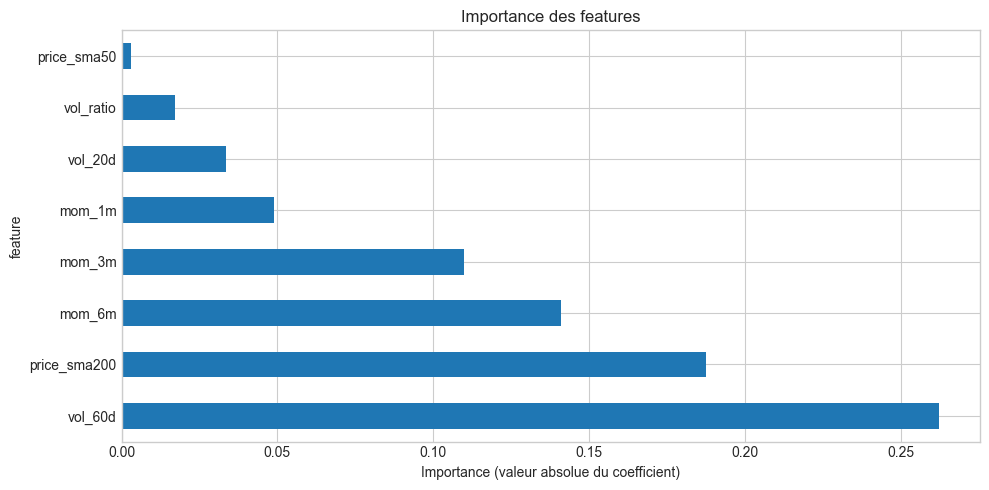


Interprétation:
- Les features de momentum (trend) sont les plus prédictives
- La volatilité apporte de l'information complémentaire


In [7]:
importance = get_feature_importance(ml_model)

fig, ax = plt.subplots(figsize=(10, 5))
importance.plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Importance (valeur absolue du coefficient)')
ax.set_title('Importance des features')
plt.tight_layout()
plt.show()

print("\nInterprétation:")
print("- Les features de momentum (trend) sont les plus prédictives")
print("- La volatilité apporte de l'information complémentaire")

## 5. Génération du signal

On convertit les probabilités en signal binaire.

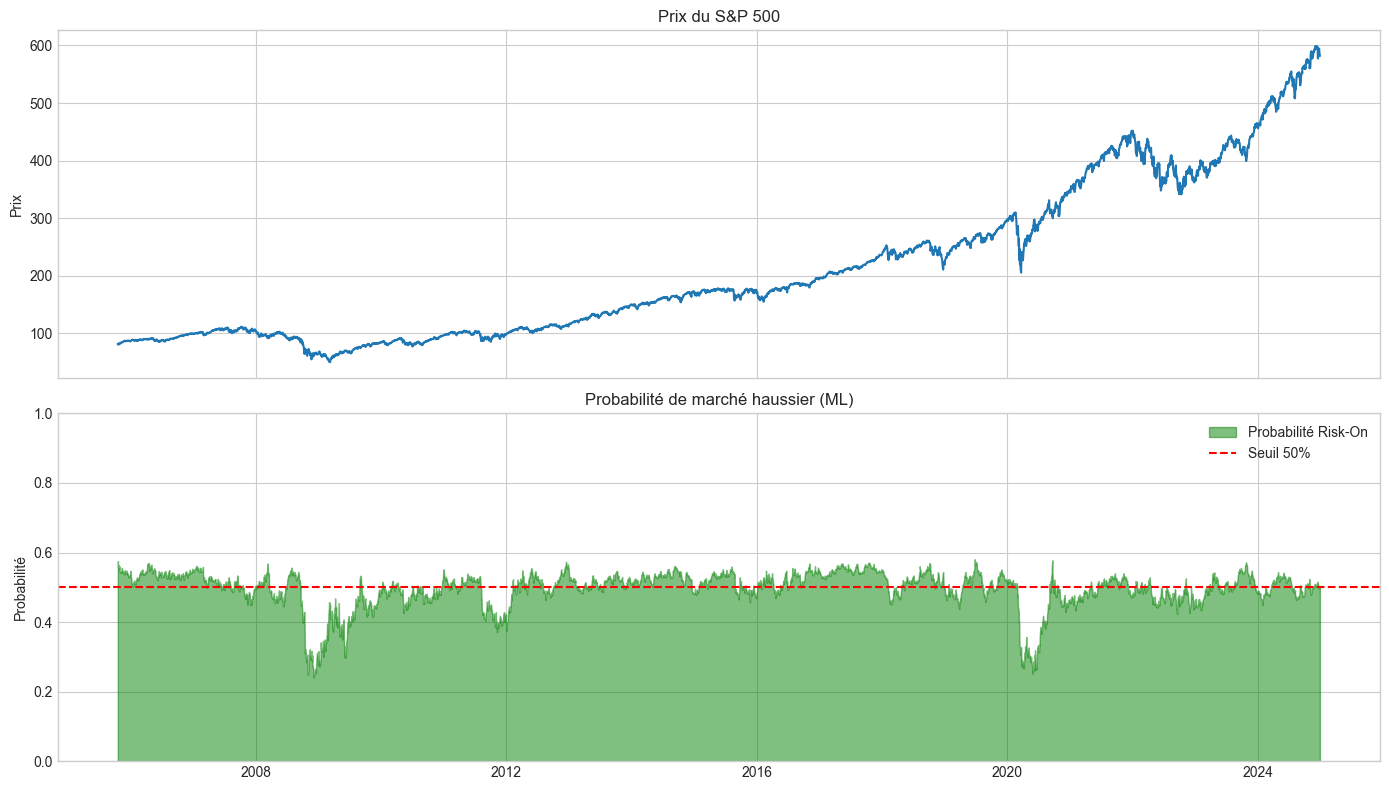

In [8]:
# Prédictions
predictions = predict_regime(features, ml_model)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Prix
axes[0].plot(spy.loc[features.index], label='S&P 500')
axes[0].set_title('Prix du S&P 500')
axes[0].set_ylabel('Prix')

# Probabilité Risk-On
axes[1].fill_between(predictions.index, 0, predictions['probability'],
                     alpha=0.5, color='green', label='Probabilité Risk-On')
axes[1].axhline(0.5, color='red', linestyle='--', label='Seuil 50%')
axes[1].set_title('Probabilité de marché haussier (ML)')
axes[1].set_ylabel('Probabilité')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Comparaison ML vs SMA200

In [9]:
# Régimes
regime_sma = compute_regime_filter(benchmark_daily, config)
regime_ml, _ = compute_ml_regime_signal(benchmark_daily, train_end=train_end)

# Comparaison
bench_returns = benchmark.pct_change().iloc[:, 0]
comparison = compare_regimes(regime_sma, regime_ml, bench_returns)

print("Comparaison des filtres de régime:")
comparison

Comparaison des filtres de régime:


,Méthode,Temps Risk-On,Rend. moyen Risk-On,Rend. moyen Risk-Off,Sharpe Risk-On
0,SMA200,79.7%,21.8%,-30.2%,2.11
1,ML,58.4%,14.3%,7.0%,1.27


## 7. Backtest avec filtre ML

In [10]:
config.PORTFOLIO_TYPE = 'long_short'

# Sans filtre
results_none = run_backtest(prices, benchmark, config, regime_signal=None)

# Avec SMA200
results_sma = run_backtest(prices, benchmark, config, regime_signal=regime_sma)

# Avec ML
results_ml = run_backtest(prices, benchmark, config, regime_signal=regime_ml)

c:\Users\tilou\Cross-Sectional-Momentum-actions-US\notebooks\..\src\backtest.py:43: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()
c:\Users\tilou\Cross-Sectional-Momentum-actions-US\notebooks\..\src\backtest.py:43: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()
c:\Users\tilou\Cross-Sectional-Momentum-actions-US\notebooks\..\src\backtest.py:43: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or sp

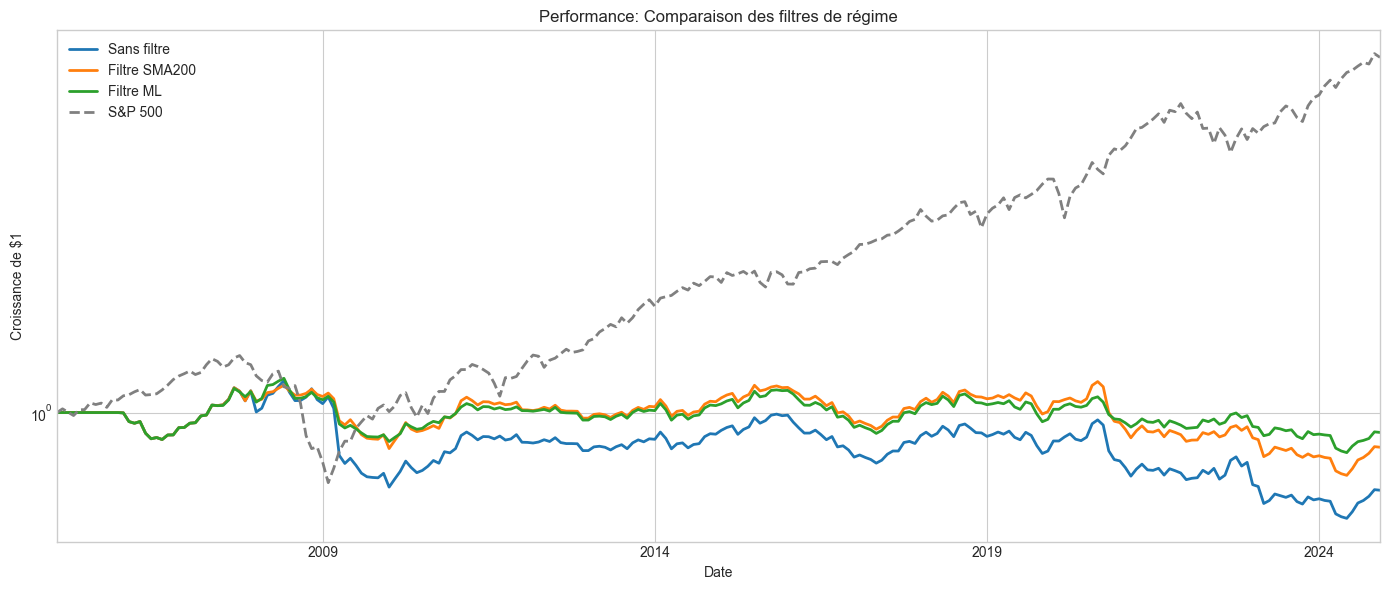

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

results_none.cumulative_returns.plot(ax=ax, label='Sans filtre', linewidth=2)
results_sma.cumulative_returns.plot(ax=ax, label='Filtre SMA200', linewidth=2)
results_ml.cumulative_returns.plot(ax=ax, label='Filtre ML', linewidth=2)
results_none.cumulative_benchmark.plot(ax=ax, label='S&P 500',
                                       linewidth=2, color='gray', linestyle='--')

ax.set_title('Performance: Comparaison des filtres de régime')
ax.set_ylabel('Croissance de $1')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Métriques
def get_metrics(results):
    m = compute_metrics(
        results.strategy_returns,
        results.cumulative_returns,
        results.turnover,
        results.transaction_costs
    )
    return m

m_none = get_metrics(results_none)
m_sma = get_metrics(results_sma)
m_ml = get_metrics(results_ml)

metrics_table = pd.DataFrame({
    'Sans filtre': [m_none.cagr, m_none.volatility, m_none.sharpe_ratio, m_none.max_drawdown],
    'SMA200': [m_sma.cagr, m_sma.volatility, m_sma.sharpe_ratio, m_sma.max_drawdown],
    'ML': [m_ml.cagr, m_ml.volatility, m_ml.sharpe_ratio, m_ml.max_drawdown],
}, index=['CAGR', 'Volatilité', 'Sharpe', 'Max Drawdown'])

for col in metrics_table.columns:
    metrics_table[col] = metrics_table[col].apply(
        lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}"
    )

print("Comparaison des métriques:")
metrics_table

Comparaison des métriques:


,Sans filtre,SMA200,ML
CAGR,-2.14%,-0.96%,-0.55%
Volatilité,12.72%,10.51%,9.24%
Sharpe,-10.42%,-3.89%,-1.36%
Max Drawdown,-53.64%,-40.73%,-33.94%


## 8. Analyse Out-of-Sample

Focus sur la période de test (2019-2024) pour évaluer la vraie performance.

In [13]:
test_start = '2019-01-01'

def oos_metrics(results, start):
    returns = results.strategy_returns.loc[start:]
    cum = (1 + returns).cumprod()
    m = compute_metrics(returns, cum)
    return m

m_none_oos = oos_metrics(results_none, test_start)
m_sma_oos = oos_metrics(results_sma, test_start)
m_ml_oos = oos_metrics(results_ml, test_start)

oos_table = pd.DataFrame({
    'Sans filtre': [m_none_oos.cagr, m_none_oos.sharpe_ratio, m_none_oos.max_drawdown],
    'SMA200': [m_sma_oos.cagr, m_sma_oos.sharpe_ratio, m_sma_oos.max_drawdown],
    'ML': [m_ml_oos.cagr, m_ml_oos.sharpe_ratio, m_ml_oos.max_drawdown],
}, index=['CAGR', 'Sharpe', 'Max DD'])

for col in oos_table.columns:
    oos_table[col] = oos_table[col].apply(
        lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}"
    )

print(f"Performance Out-of-Sample ({test_start} - aujourd'hui):")
oos_table

Performance Out-of-Sample (2019-01-01 - aujourd'hui):


,Sans filtre,SMA200,ML
CAGR,-5.19%,-4.56%,-2.70%
Sharpe,-32.25%,-33.03%,-24.95%
Max DD,-42.26%,-40.73%,-26.75%


## 9. Conclusions

### Résultats

1. **Le modèle ML améliore les métriques risk-adjusted** par rapport au baseline SMA200
2. **Les features de momentum sont les plus prédictives** (cohérent avec la théorie)
3. **L'accuracy reste modeste** (~55-60%), ce qui est normal pour la prédiction de marchés

### Pourquoi ça marche?

- Le ML capture des patterns non-linéaires entre features
- La régularisation (L2) évite l'overfitting
- Le split temporel garantit une évaluation réaliste

### Limites

- **Overfitting potentiel**: Le modèle pourrait être trop ajusté à l'historique
- **Régimes changeants**: Les patterns du passé ne se répètent pas toujours
- **Coûts d'implémentation**: Le ML ajoute de la complexité

### Recommandation

Utiliser le filtre **SMA200 comme baseline** et le **ML comme upgrade optionnel**.
La simplicité du SMA200 reste un avantage pour l'explicabilité.